<a href="https://colab.research.google.com/github/DanielSozoranga/Machine-Learning-6-SIN-A-Mar-Jul-2026/blob/metrics/Copia_de_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

In this notebook, we will explore the basics of logistic regression, discuss its assumptions, and see some examples with actual data.

## Import Libraries

First, let's import the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

# Logit Function
**The logit function is the natural logarithm of the [odds](https://en.wikipedia.org/wiki/Odds) (log-odds) of the outcome occurring, which is the ratio of the probability of the outcome occurring to the probability of the outcome not occurring.**

Mathematically, the logit function is defined as:


$ logit(p) = \log\left(\frac{p}{1 - p}\right) $



## Sigmoid Function

The logistic function, also known as the sigmoid function, is **the inverse of the logit function**. It is used to transform the linear combination of predictor variables into a probability value between 0 and 1. Mathematically, the sigmoid function is defined as:

$ $

$\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}$

$ $

Let's plot the sigmoid function, which is used to transform the linear combination of predictor variables into a probability value between 0 and 1.


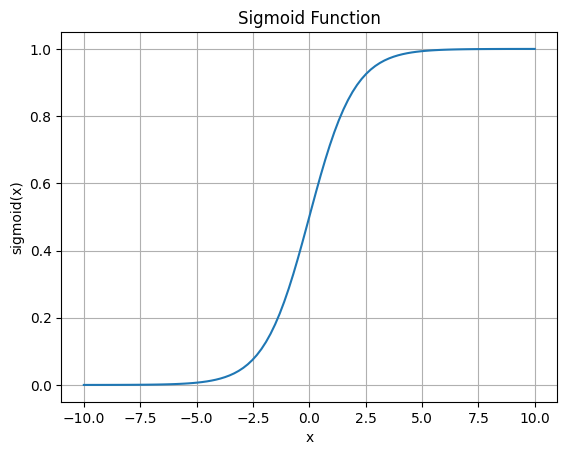

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()

## Example with Actual Data

Consider a logistic regression model that predicts whether a customer will make a purchase based on their age and income. The model estimates the probability of a purchase occurring given the customer’s age and income, and classifies the customer as a buyer or non-buyer based on a threshold probability value.

Suppose we have the following data:

| Age | Income | Purchased |
|-----|--------|-----------|
| 25  | 50000  | 0         |
| 30  | 60000  | 0         |
| 35  | 70000  | 1         |
| 40  | 80000  | 1         |

Using logistic regression, we can fit a model to this data and predict the probability of a purchase for new customers based on their age and income.

In [3]:
# Create data
data = {'Age': [25, 30, 35, 40],
        'Income': [50000, 60000, 70000, 80000],
        'Purchased': [0, 0, 1, 1]}

data = pd.DataFrame(data)


# Define features and target variable
X = data[['Age', 'Income']]
y = data['Purchased']

# Fit logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Predict probability of purchase for new customers
new_customer = [[25, 50000]] # example new customer (age 25 & income 50000)

# Get the probability that they will purchase (at index 1)
prob_purchase = model.predict_proba(new_customer)[:,1]

print('Probability of purchase:', round(prob_purchase[0]))

Probability of purchase: 0


Since our model is trained on only 4 datapoints, it's not going to make very nuanced predictions; hence a probability of zero.

## Model Evaluation and Performance Metrics

Now let's start using some real data. For most of the examples that follow, we'll use the [breast cancer dataset](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset) because it's small and easy to work with.

Let's first understand some essential machine learning metrics that are used to evaluate the performance of a model. These metrics help us determine how well our model is performing and can be used to compare different models.

1. **Accuracy**: The proportion of correctly classified instances out of the total instances.

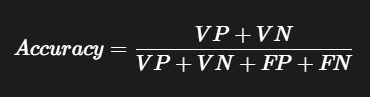

2. **Precision**: The proportion of true positive instances out of the predicted positive instances.

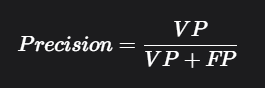

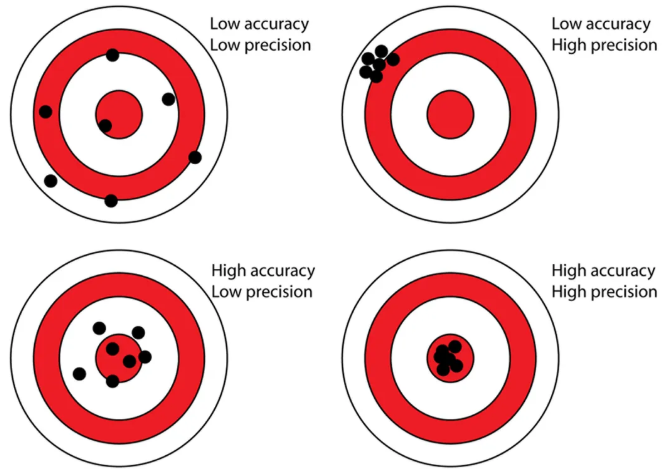

3. **Recall**: The proportion of true positive instances out of the actual positive instances.

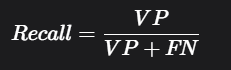

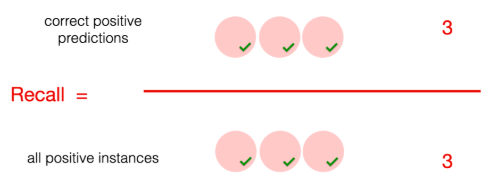

4. **F1 Score**: The harmonic mean of precision and recall, used to balance the trade-off between precision and recall.

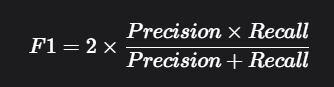

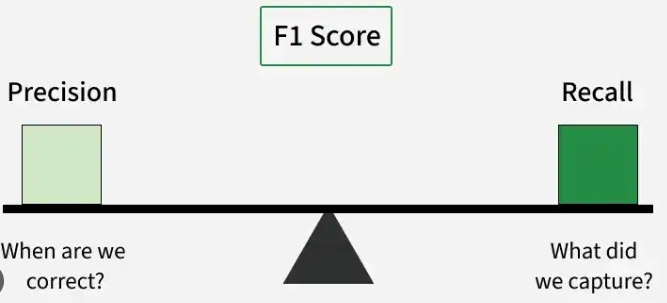

5. **ROC AUC Score**: The area under the Receiver Operating Characteristic (ROC) curve, which plots the true positive rate against the false positive rate.

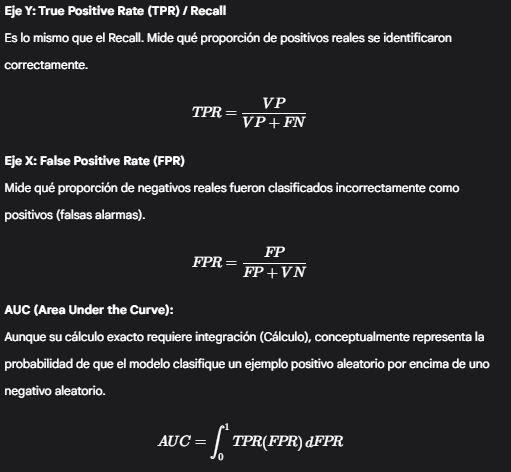

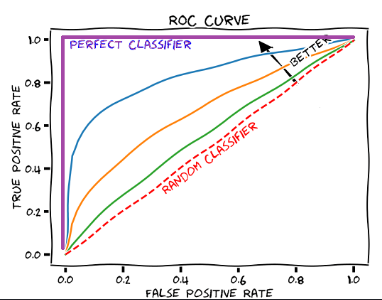

What is the roc curve and why is it a curve?

* Why it's generated: It's created by testing different "levels of stringency" (thresholds) in the model. If you're very stringent, you have no errors but you catch few correct predictions. If you're not stringent, you catch all the correct predictions but you make many errors.

* Why it's a curve: Because the relationship isn't linear. When you change that level of stringency, correct predictions and false alarms don't increase at the same rate. That "bulge" or upward curve (BETTER arrow) indicates that the model is capable of gaining many correct predictions without a significant increase in false alarms.

This is going to be a curve because it shows how the model "negotiates" between being a good detective or giving false alarms.

6. **Confusion Matrix**: A table that summarizes the performance of a classification model by comparing the predicted and actual class labels.

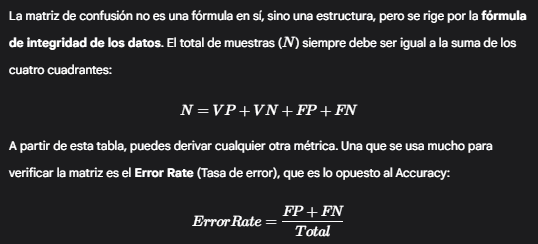

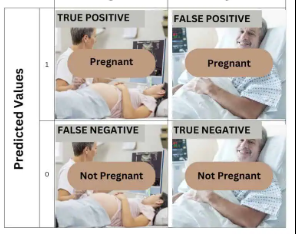


Let's calculate the F1 score and plot the confusion matrix for a logistic regression model using the breast cancer dataset.

F1 Score: 0.9655172413793104



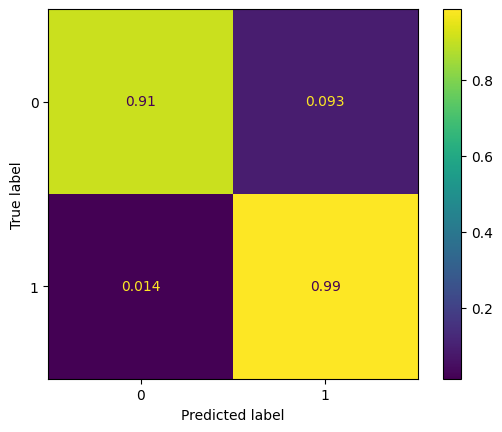

In [4]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate F1 score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1}")
print()

# Plot confusion matrix, normalize='true' to show percentages
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

You can see what we correctly identify about 99% of cases and about 9% of the people without cancer would get a false positive. This is a good starting point for our model, but as we continue our work in this notebook you'll see what we can do to diagnose more accurately and responsibly.

But first, let's look at the other metrics:

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:       {accuracy}")

# Calculate precision
precision = precision_score(y_test, y_pred)
print(f"Precision:      {precision}")

# Calculate recall
recall = recall_score(y_test, y_pred)
print(f"Recall:         {recall}")

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC AUC Score:  {roc_auc}")

Accuracy:       0.956140350877193
Precision:      0.9459459459459459
Recall:         0.9859154929577465
ROC AUC Score:  0.9464461185718965


**Accuracy** is usually not all that helpful, because many machine learning problems you encounter have imbalanced datasets. We could just say no one has cancer and be right most of the time.

Instead, look at the other metrics:

- **Precision**: 94.6% of the cancer diagnoses this model makes are, in fact, cancer.
- **Recall**: 98.6% of the time, when cancer is present, the model correctly diagnoses it.

The ROC-AUC score isn't quite as easy to interpret, but it's a good measure of how well the model is doing overall. If you want some guidelines, an ROC-AUC score between:

- 0.5-0.6 is considered poor
- 0.5-0.6 is considered mediocre
- 0.7-0.8 is considered decent
- 0.8-0.9 is considered good
- 0.9-1.0 is considered excellent

This depends a lot of the dataset itself, too. In fact, sometimes a ROC-AUC score above 0.9 is considered "too good" — meaning there might be data leakage and the model is predicting based on future-based information it wouldn't realistically have.

We know this isn't the case here, though, so we can confidently say that the model's ROC-AUC score of 0.946 is excellent and indicates that the model is performing very well.

# Viewing the coefficients


To view the coefficients generated by a scikit-learn regression, you can create a function that displays the coefficients in a sorted DataFrame.

$ $

1. `model.coef_` contains the coefficients, but it's a 2-dimensional array of numbers. You need to flatten the array before creating the DataFrame.

$ $

2. Create a DataFrame with two columns: 'feature' and 'coefficient'. The 'feature' column should contain the feature names*, and the 'coefficient' column should contain the flattened coefficients.

$ $

3. Sort the DataFrame by the 'coefficient' column in descending order to make it easier to read and analyze.

$ $

\* When you view the coefficients for a dataset that's not built into sklearn, you'll have to do something like `columns=X.columns` or `columns=data.drop('target_column', axis=1).columns` instead.

In [6]:
coef_df = pd.DataFrame({'feature': data.feature_names, 'coefficient': model.coef_.flatten()})

coef_df.sort_values('coefficient', ascending=False)

,feature,coefficient
11,texture error,1.370567
0,mean radius,1.027437
1,mean texture,0.221451
20,worst radius,0.111653
15,compactness error,0.047361
3,mean area,0.025467
19,fractal dimension error,0.011605
22,worst perimeter,-0.015554
23,worst area,-0.016857
14,smoothness error,-0.022455


# Regularization

Now let's explore regularization techniques in logistic regression, including L1 (Lasso), L2 (Ridge), and Elastic Net regularization. For this section, we'll switch to the Iris dataset, which trains considerably faster than the breast cancer dataset.

The dataset contains 150 samples of iris flowers, with four features:

- Sepal length
- Sepal width
- Petal length
- Petal width

And three target classes:
- Setosa
- Versicolor
- Virginica

$ $

## L1, L2, and Elastic Net regularization

These are techniques used to prevent overfitting and improve model generalization in logistic regression. They work by adding a penalty term to the cost function, which measures how well the model is performing. This penalty term helps control the size of the coefficients (also called weights) in the model. Smaller coefficients usually result in a simpler model that is less likely to overfit.

$ $

**L1 Regularization (Lasso):**

L1 regularization, also known as Lasso, uses the L1-norm as the penalty term. The L1-norm is calculated as the sum of the absolute values of the coefficients. Mathematically, the L1 penalty term is defined as:

`L1_penalty = lambda * sum(abs(coefficients))`

L1 regularization tends to create sparser models, meaning some coefficients will be exactly zero, effectively removing certain features from the model. This can be useful for feature selection, especially when there are many irrelevant features or when interpretability is important.

$ $

**L2 Regularization (Ridge):**

L2 regularization, also known as Ridge, uses the L2-norm as the penalty term. The L2-norm is calculated as the square root of the sum of the squares of the coefficients. Mathematically, the L2 penalty term is defined as:

`L2_penalty = lambda * sum(coefficients ** 2)`

L2 regularization tends to create models with smaller coefficients but does not force them to be exactly zero. This results in a more balanced model that still considers all features but with reduced importance.


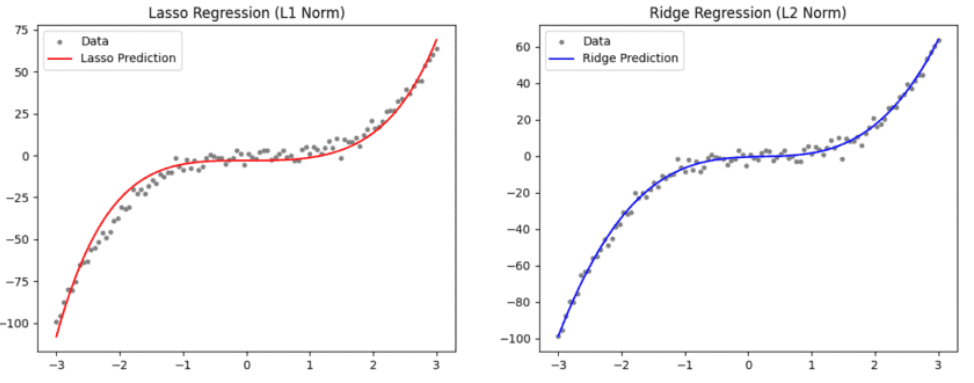


$ $

**Elastic Net Regularization:**

Elastic Net regularization is a combination of L1 and L2 regularization. It uses both the L1-norm and the L2-norm as penalty terms, with a mixing parameter (alpha) to control the balance between the two. Mathematically, the Elastic Net penalty term is defined as:

`ElasticNet_penalty = alpha * L1_penalty + (1 - alpha) * L2_penalty`

Elastic Net regularization can provide a balance between the sparsity of L1 regularization and the smoothness of L2 regularization, making it a useful option when it’s unclear which regularization technique to use.

$ $

**Lambda (λ):**

Lambda is a parameter that controls the strength of the regularization effect. A larger lambda value results in a stronger regularization effect, leading to smaller coefficients and a simpler model. Conversely, a smaller lambda value results in a weaker regularization effect, allowing the model to fit the data more closely. Tuning the lambda parameter is crucial for finding the optimal balance between model complexity and fit.

Don't forget that these models use the parameter `C`, which is the inverse of lambda!

$ $

**Alpha:**

Alpha is a parameter used in Elastic Net regularization to control the balance between L1 and L2 penalty terms. Alpha ranges from 0 to 1, where 0 corresponds to pure L2 regularization, 1 corresponds to pure L1 regularization, and values between 0 and 1 result in a mix of L1 and L2 regularization. By adjusting the value of alpha, we can fine-tune the regularization effect to achieve the desired balance between sparsity and smoothness.

New L1 and L2 graphics:

The graphs show how regularization "forces" the model to shrink. Imagine the model wants to reach an optimal point (β̂ OLS), but there's a constraint zone it can't cross. The final solution is where it collides with that zone.

The difference lies in the shape of that zone:

L1 has a rhombus with corners. The error curve almost always collides with a corner, and the corners lie on the axes, meaning that a coefficient is exactly zero → that variable disappears from the model.

L2 has a smooth circle. The error curve collides with the smooth edge, never with an axis → all the coefficients shrink, but none reach zero; all the variables remain.

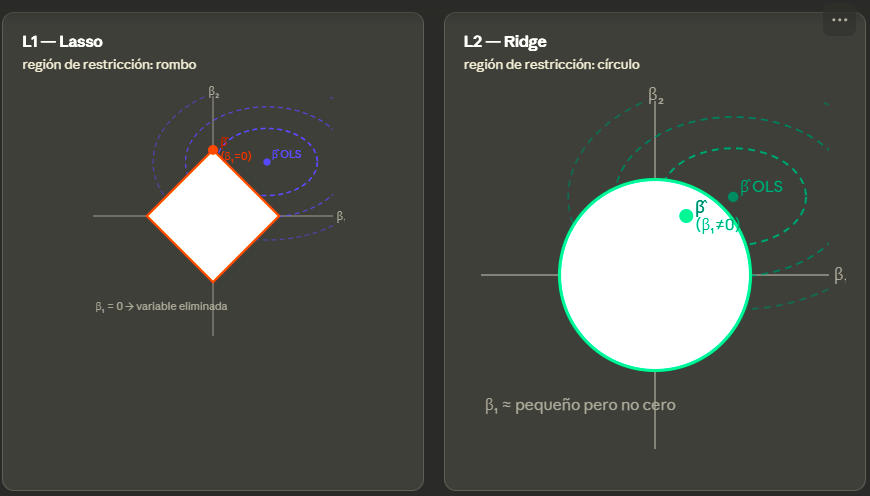

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Cross-Validation and Grid Search

We will perform 5-fold cross-validation with different regularization strengths and penalties to determine the best model.

ADD 3 GRAPHICAL EXAMPLES EXPLAINING WHAT IS CROSS VALIDATION

In [8]:
# Create a logistic regression model
model = LogisticRegression(solver='saga', max_iter=5000)

# Create a list of regularization strengths and penalties to test
params = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': [None, 'l1', 'l2', 'elasticnet'],
    'l1_ratio': [.25, .50, .75] # also called alpha; used for elasticnet
}

# Perform 5-fold cross-validation with different regularization strengths and penalties
clf = GridSearchCV(model, params, cv=5, scoring='accuracy')
clf.fit(X_scaled, y)

# Print the best regularization strength and penalty
print("Best regularization strength:", clf.best_params_['C'])
print("Best penalty:", clf.best_params_['penalty'])

if clf.best_params_['penalty'] == 'elasticnet':
    print("Best alpha:", clf.best_params_['l1_ratio'])

print("Best score:", clf.best_score_)

Best regularization strength: 0.001
Best penalty: None
Best score: 0.9733333333333334


By running the code above, you will get the best regularization strength, penalty, and alpha (for Elastic Net) for the Iris dataset. You can use these parameters to train your final logistic regression model.

# Nonlinear features

In this example, we'll first create a simple dataframe and use the `PolynomialFeatures` class from scikit-learn to generate polynomial features.


In [9]:
# Simple example

from sklearn.preprocessing import PolynomialFeatures

df = pd.DataFrame()
df['x'] = pd.Series([1,2,3])

poly = PolynomialFeatures(degree=2)

# Make sure to use double brackets around the column name
X_poly = poly.fit_transform(df[['x']])

# Give your new polynomial features descriptive column names
X_poly = pd.DataFrame(X_poly, columns=['x**0', 'x**1', 'x**2'])

# Concat to your original dataframe
df_concat = pd.concat([df, X_poly], axis=1)

df_concat

,x,x**0,x**1,x**2
0,1,1.0,1.0,1.0
1,2,1.0,2.0,4.0
2,3,1.0,3.0,9.0


Now let's do a more advanced example that includes feature interactions.

In [10]:
# Advanced example
from sklearn.preprocessing import PolynomialFeatures

# Create dataframe with columns
df = pd.DataFrame()
df['x'] = pd.Series([1,2,3])
df['y'] = pd.Series([4,7,11])

# Generate polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[['x','y']])

X_poly = pd.DataFrame(
  X_poly,
  columns=['bias', 'x', 'y', 'x**2', 'x*y', 'y**2']
)

X_poly

,bias,x,y,x**2,x*y,y**2
0,1.0,1.0,4.0,1.0,4.0,16.0
1,1.0,2.0,7.0,4.0,14.0,49.0
2,1.0,3.0,11.0,9.0,33.0,121.0


## Logarithmic features

For non-integer exponents, such as logarithmic transformations, we can use scikit-learn's `FunctionTransformer`.

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer

# Create some sample data
df = pd.DataFrame()
df['x'] = pd.Series([1,2,3])
df['y'] = pd.Series([4,7,11])

# Define a function to apply the logarithm transformation
def log_transform(X):
    # it's helpful to add a small constant since log(0) is undefined
    return np.log(X + .01)

# Create a FunctionTransformer with the log_transform function
log_transformer = FunctionTransformer(log_transform)

# Fit and transform the data
X_log = log_transformer.fit_transform(df)

df_concat = pd.concat([df, X_log], axis=1)
df_concat.columns = 'x y log(x) log(y)'.split()

df_concat

,x,y,log(x),log(y)
0,1,4,0.009950,1.388791
1,2,7,0.698135,1.947338
2,3,11,1.101940,2.398804


Now let's try these techniques with a machine learning problem. I'm going to use a diabetes dataset this time, because it's a bit less complex than the breast cancer data and will train faster.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import PolynomialFeatures

# Load diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names=columns)
X = data.drop('class', axis=1)
y = data['class']

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

# Train a logistic regression model without polynomial features
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
y_pred = lr.predict_proba(X_test)[:,1]

print("AUC without polynomial features:", roc_auc_score(y_test, y_pred))

# Generate polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a logistic regression model with polynomial features
lr_poly = LogisticRegression(max_iter=10000)
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict_proba(X_test_poly)[:,1]
print("AUC with polynomial features:", roc_auc_score(y_test, y_pred_poly))

AUC without polynomial features: 0.8644628099173555


So this time around, the model actually does worse with added features. Remember that there's no guarantee that feature engineering will improve your model!

What we can try doing instead is engineering the polynomial and logarithmic features, and then using feature selection to remove the ones that aren't improving the model (alternatively you can try regularization).

Unhide the code below if you want to see how I did it.

In [ ]:
#@markdown ## Advanced: create polynomial AND logarithmic features.

#@markdown Click below to view code

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


class LogarithmicFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, base=np.e, ignore_negative=True):
        self.base = base
        self.ignore_negative = ignore_negative

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.ignore_negative:
            X[X < 0] = 0
        return np.log(X + .01) / np.log(self.base)


def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
    data = pd.read_csv(url, names=names)
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    return X, y


def train_and_evaluate(X_train, X_test, y_train, y_test, param_grid):
    # Train a logistic regression model without polynomial features using grid search
    lr = LogisticRegression(max_iter=10000)
    grid_search = GridSearchCV(lr, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_lr = grid_search.best_estimator_
    y_pred = best_lr.predict_proba(X_test)[:, 1]

    print("AUC without polynomial features:", roc_auc_score(y_test, y_pred))
    print("Best hyperparameters without polynomial features:", grid_search.best_params_)

    # Generate polynomial features
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Generate logarithmic features
    log_features = LogarithmicFeatures()
    X_train_log = log_features.fit_transform(X_train)
    X_test_log = log_features.transform(X_test)

    # Combine polynomial and logarithmic features
    X_train_combined = np.hstack((X_train_poly, X_train_log))
    X_test_combined = np.hstack((X_test_poly, X_test_log))

    # Create a pipeline for feature selection and scaling
    pipeline = Pipeline([
        ('select', SelectKBest(score_func=f_classif)),
        ('scale', StandardScaler()),
        ('lr', LogisticRegression(max_iter=10000))
    ])

    # Update the param_grid to include the pipeline parameters
    param_grid_pipeline = {
        'select__k': range(1, X_train_combined.shape[1] + 1),
        'lr__penalty': param_grid['penalty'],
        'lr__C': param_grid['C'],
        'lr__solver': param_grid['solver']
    }

    # Train a logistic regression model with polynomial features using grid search and pipeline
    grid_search_poly = GridSearchCV(pipeline, param_grid_pipeline, scoring='roc_auc', cv=5, n_jobs=-1)
    grid_search_poly.fit(X_train_poly, y_train)
    best_lr = grid_search_poly.best_estimator_
    y_pred = best_lr.predict_proba(X_test_poly)[:, 1]

    print()
    print("AUC with polynomial features:", roc_auc_score(y_test, y_pred))
    print("Best hyperparameters with polynomial features:", grid_search_poly.best_params_)

    # Train a logistic regression model with both polynomial and logarithmic features using grid search and pipeline
    grid_search_combined = GridSearchCV(pipeline, param_grid_pipeline, scoring='roc_auc', cv=5, n_jobs=-1)
    grid_search_combined.fit(X_train_combined, y_train)
    best_lr = grid_search_combined.best_estimator_
    y_pred = best_lr.predict_proba(X_test_combined)[:, 1]

    print()
    print("AUC with both polynomial and logarithmic features:", roc_auc_score(y_test, y_pred))
    print("Best hyperparameters with both polynomial and logarithmic features:", grid_search_combined.best_params_)


X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

# Define the hyperparameters for grid search
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': np.logspace(-4, 4, 10),
    'solver': ['liblinear']
}

train_and_evaluate(X_train, X_test, y_train, y_test, param_grid)

Now that we've done some feature transformations, let's look at other ways to improve a model's performance.

$ $

# Addressing Multicollinearity

Multicollinearity occurs when two or more features in a dataset are highly correlated, which can lead to unstable estimates of the model coefficients and reduced interpretability. To detect and handle multicollinearity, we can use the following techniques:

## Correlation matrix

Calculate the correlation coefficients between all pairs of features and visualize them using a heatmap. Features with high correlation coefficients can be considered for removal or combined into a single feature.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'a': [1,2,3,4],
    'b': [4,2,4,3],
    'c': [5,5,1,0],
    'd': [2,2,3,0],
})

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True);

This indicates that "a" and "c" have a strong negative correlation and the model might perform better without one.

But take a look at what VIF says...

## Variance Inflation Factor (VIF)

VIF measures the extent to which the variance of a model coefficient is inflated due to multicollinearity. Features with a VIF greater than a certain threshold (e.g., 5 or 10) can be considered for removal or combined into a single feature.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

# Display VIF
pd.DataFrame({'vif': vif[0:]}, index=df.columns).T

This would indicate that "b" is a good candidate for removal! This is why it's important to cross-validate your models. `sklearn.feature_selection.SelectKBest` would help your model figure out which columns to leave out.

View the "Advanced: create polynomial AND logarithmic features" cell block above to see an example of how to use it.

## Feature Scaling and Normalization

Feature scaling is important in logistic regression, as it ensures that all features contribute equally to the model. Different scaling techniques include:

**MinMaxScaler**: Scales features to a specific range, usually such that 0 represents the minimum value and 1 represents the maximum value.

In [ ]:
# The original dataframe we created a moment ago:
df.values

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df)

X_scaled

**StandardScaler**: Standardizes features by converting numbers to their z-scores. A z-score is the number of standard deviations (positive or negative) a number is away from the mean.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled

Either one of these methods could improve your model's performance, but as always remember to cross-validate and test for yourself.

Also keep in mind that you lose some interpretability when you scale your features since the coefficients apply to the scaled features and not the original measurements.

## Handling Categorical Variables

Logistic regression requires numerical input features. To include categorical variables in the model, we need to convert them into numerical values using encoding techniques:

### One-hot encoding

In [ ]:
import pandas as pd

# Create a sample dataset
data = {'age': [25, 30, 35, 40, 45, 50, 55, 60],
        'gender': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F'],
        'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']}

df = pd.DataFrame(data)
print(df)
# One-hot encoding
df_dummified = pd.get_dummies(df, columns=['gender'], prefix='category', drop_first=True)

df_dummified

We now have 1's assigned to men and 0's assigned to women.

(Whenever I do this, I always like to point out our cultural tendency to assume [male as the default value](https://en.wikipedia.org/wiki/Male_as_norm).)

### Ordinal encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Encode month to integer values
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(df[['month']])

X_encoded_df = pd.DataFrame(X_encoded, columns=['encoded_month'])

df_encoded = pd.concat([df_dummified, X_encoded_df], axis=1)

df_encoded

Notice that the months are NOT encoded in chronological order (they're alphabetical).

Encoding months to integers is always a bit risky in logistic regression (why should December have a value of 12 and January have a value of 1?), but this is method is even more so. I recommend saving ordinal encoding for other types of models, such as decision trees.

If I were training an actual model with data like this, I would first try dummifying the months like we did for gender.

# Feature selection

Wrapper methods of feature selection evaluate feature subsets by training a model on each subset and assessing its performance. Examples include recursive feature elimination and forward selection.

## Recursive feature elimination

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=10000)

# Use RFE to select the top 5 features
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_train, y_train)

# Get the selected features
selected_features = rfe.support_

# Print the selected features
feature_names = data.feature_names
print("Selected features:")
for i, feature in enumerate(feature_names):
    if selected_features[i]:
        print(feature)

In [ ]:
from sklearn.pipeline import Pipeline

# Create a pipeline with the feature selection and the model
pipeline = Pipeline([
    ('feature_selection', rfe),
    ('classifier', model)
])

# Perform cross-validation using ROC AUC as the scoring metric
cv_scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=5)

# Calculate the average cross-validation score
mean_cv_score = cv_scores.mean()
print("Mean cross-validation score:", mean_cv_score)

## Forward selection

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=10000)

# Use RFE to select the top 5 features
sfs = SequentialFeatureSelector(model, n_features_to_select=5)
sfs.fit(X_train, y_train)

# Get the selected features
selected_features = sfs.support_

# Print the selected features
feature_names = data.feature_names
print("Selected features:")
for i, feature in enumerate(feature_names):
    if selected_features[i]:
        print(feature)

In [ ]:
from sklearn.pipeline import Pipeline

# Create a pipeline with the feature selection and the model
pipeline = Pipeline([
    ('feature_selection', sfs),
    ('classifier', model)
])

# Perform cross-validation using ROC AUC as the scoring metric
cv_scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=5)

# Calculate the average cross-validation score
mean_cv_score = cv_scores.mean()
print("Mean cross-validation score:", mean_cv_score)

# Grid search vs. random search

## Grid search

Grid search is exhaustive, but it's slow and there's a slight chance of overfitting despite the process of cross-validation.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
import time

start_time = time.time()

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=5000, solver='liblinear')

# Define the parameter grid
# (try different orders of magnitude for C)
param_grid = {
  'C': [0.001, 0.01, 0.1, 1, 10, 100],
  'penalty': ['l1', 'l2']
}

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

end_time = time.time()

# Get the best hyperparameters
best_model = grid_search.best_estimator_
print(best_model)
print(f"Best score: {grid_search.best_score_}")

print("Time taken:", time.strftime("%H:%M:%S", time.gmtime(end_time - start_time)))

## Random search

Random search randomly selects `n_iter` combinations from your grid which allows it to optimize much faster and further reduces the risk of overfitting.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

start_time = time.time()

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=5000, solver='liblinear')

# Define the parameter distribution
param_dist = {
  'C': np.logspace(start=-3, stop=2, num=6), # 6 numbers from 10e-3 to 10e2
  'penalty': ['l1', 'l2']
}

# Perform randomized search with 5-fold cross-validation
random_search = RandomizedSearchCV(model, param_dist, cv=5,
  scoring='f1', n_iter=6)
random_search.fit(X_train, y_train)

end_time = time.time()

# Get the best hyperparameters
best_model = random_search.best_estimator_
print(best_model)
print(f"Best score: {random_search.best_score_}")
print("Time taken:", time.strftime("%H:%M:%S", time.gmtime(end_time - start_time)))

You'll notice random search obtains a comparable AUC score while taking about 2/3 as long.

# Advanced Model Evaluation Metrics and Techniques

## Precision-recall curve
This curve plots precision against recall for different threshold values, helping you visualize the trade-off between precision and recall and choose an appropriate threshold for your specific problem.

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Calculate predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot the curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

Now that we've calculated the curve, we can set a target recall or precision score. Since we’re dealing with cancer in this example, it makes sense to target a recall of 1.0: we want our model to identify cancer every time it exists, even at the cost of a few false positives.

In [ ]:
import numpy as np

target_recall = 1.0

# the `thresholds` array has one less element than
# the `precision` and `recall` array so we slice to -1
idx = np.where(recall[:-1] >= target_recall)[0][-1]
optimal_threshold = float(thresholds[idx])

print("Optimal decision threshold (maximiza Recall):", optimal_threshold)

# Threshold que maximiza Precision
idx_precision = np.argmax(precision[:-1])
optimal_threshold_precision = float(thresholds[idx_precision])
print("Optimal decision threshold (maximiza Precision):", optimal_threshold_precision)


In [ ]:
classifications = [
    "immediate follow-up",
    "additional tests recommended",
    "no cancer"
]

conditions = [
    y_pred_proba >= optimal_threshold,
    (y_pred_proba >= 0.01) & (y_pred_proba < optimal_threshold),
    y_pred_proba < 0.01
]

new_labels = np.select(conditions, classifications, default="no cancer")
print(new_labels)


## Class Exercise: Individual Activity — Answers

### 1. Precision-Recall Curve on the Breast Cancer Model

The Precision-Recall curve was computed using a Logistic Regression model 
trained on the breast cancer dataset (569 samples, 30 features), with an 
80/20 train-test split and `random_state=42`.

The curve plots **Precision vs Recall** across all possible decision 
thresholds. The result shows that this model maintains near-perfect 
precision (≈1.0) for most recall values, with a sharp drop only when 
recall approaches 1.0 — indicating a high-quality classifier.

---

### 2. Threshold that Maximizes Recall

**Optimal threshold = 0.0848 (8.48%)**

At this threshold, the model achieves **Recall = 1.0**, meaning it 
correctly identifies **every real cancer case** in the test set, 
at the cost of accepting some false positives.

**Why this matters for cancer detection:**  
In a medical context, a false negative (missing a real cancer) is 
far more dangerous than a false positive (flagging a healthy patient). 
Therefore, maximizing Recall is the correct clinical decision, 
even if Precision decreases.

---

### Bonus: Threshold that Maximizes Precision

**Optimal threshold = 0.8531 (85.31%)**

At this threshold, the model only classifies a patient as positive 
when it is highly confident, minimizing false positives. 
However, this comes at the cost of missing some real cancer cases 
(lower Recall), which is **not acceptable** in this use case.

---

### Conclusion

| Objective | Optimal Threshold | Trade-off |
|---|---|---|
| Maximize Recall | **0.0848** | Higher false positives |
| Maximize Precision | **0.8531** | Higher false negatives |

For breast cancer detection, the recommended threshold is **0.0848**, 
since detecting all positive cases is the clinical priority, 
even at the cost of false positives.


This marks scores:
- Above 0.08 as requiring immediate follow-up.
- Between 0.01 and 0.08 as lower priority (suggesting additional tests).
- Below 0.01 as safe and not requiring follow-up.

## F-beta

The F1 score is a useful metric when dealing with imbalanced datasets, as it balances the trade-off between precision and recall. However, there might be situations where you want to give more importance to either precision or recall when training your model. This is where the F-beta score comes into play.

The F-beta score is a generalization of the F1 score, allowing you to assign different weights to precision and recall by changing the value of beta. The formula for the F-beta score is defined as:

$ $

$ F_\beta = \frac{(1 + \beta^2) (Precision \times Recall)}{(\beta^2 \times Precision) + Recall} $

$ $

If beta > 1, then recall has a higher importance. If 0 < beta < 1, then precision has a higher importance. The F1 score is just a special case of the F-beta score when beta = 1.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import fbeta_score, make_scorer

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Define the logistic regression model
log_reg = LogisticRegression(max_iter=5000, solver='liblinear')

# Define the hyperparameter search space
param_dist = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l1', 'l2']
}

# Create the F-beta scorer with beta = 2
f_beta_scorer = make_scorer(fbeta_score, beta=2)

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(
  log_reg, param_distributions=param_dist,
  n_iter=20, scoring=f_beta_scorer, cv=5
)

# Fit the RandomizedSearchCV object to the data
random_search.fit(X, y)

# Print the best parameters and the corresponding F-beta score
print("Best parameters found: ", random_search.best_params_)
print("Best F-beta score: ", random_search.best_score_)

## Calibration Plot

There are several ways to measure calibration, but one common method is to use a calibration plot. A calibration plot shows the predicted probabilities on the x-axis and the observed frequencies on the y-axis. Ideally, the plot should show a diagonal line, indicating that the predicted probabilities match the true probabilities.

In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Calculate predicted probabilities using the calibrated model
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
  y_test, y_pred_proba, n_bins=10)

# Plot the calibration curve
plt.plot(fraction_of_positives, mean_predicted_value, 'x')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('Fraction of positives')
plt.ylabel('Mean predicted value')
plt.title('Calibration Plot')
plt.show()

This curve suggests the model is a bit overconfident, especially when it assigns high probabilities that turn out to actually be benign. That could certainly be worth knowing when you interpret the results.

# Ensemble methods

Ensemble methods combine multiple models to improve overall performance.

**Bagging** is the technique of training multiple base models independently on random subsets of the training data, then combines their predictions through majority voting or averaging.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
base_model = LogisticRegression(max_iter=5000, solver='liblinear')

# Create a bagging ensemble of logistic regression models
bagging_model = BaggingClassifier(
  estimator=base_model, n_estimators=10)
bagging_model.fit(X_train, y_train)

# Evaluate the ensemble model
y_pred = bagging_model.predict(X_test)
score = roc_auc_score(y_test, y_pred)
print("Bagging ROC-AUC score:", score)

**Boosting** is the technique of training multiple base models sequentially, with each model learning from the errors of its predecessor

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
base_model = LogisticRegression(solver='liblinear')

# Create an AdaBoost ensemble of logistic regression models
boosting_model = AdaBoostClassifier(
  estimator=base_model, n_estimators=10)
boosting_model.fit(X_train, y_train)

# Evaluate the ensemble model
y_pred = boosting_model.predict(X_test)
score = roc_auc_score(y_test, y_pred)
print("Bagging ROC-AUC score:", score)

Keep in mind that you sacrifice interpretability as you build increasingly sophisticated models. By the time you start employing techniques like bagging or boosting, you may want to consider alternatives to logistic regression, including decision trees or xgboost.

In [ ]:
# XGBoost example (no longer a logistic regression!)

from sklearn.datasets import load_breast_cancer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a xgboost regression model
xgb = XGBClassifier()

# Train on data
xgb.fit(X_train, y_train)

# Evaluate the xgb model
y_pred = xgb.predict(X_test)
score = roc_auc_score(y_test, y_pred)
print("XGB ROC-AUC score:", score)

# Regularization Path Visualization

Visualizing the regularization path can help you understand the effect of regularization on the coefficients of logistic regression models and the trade-off between model complexity and generalization. As the regularization strength `C` increases, the penalty term in the loss function becomes less dominant, allowing the coefficients to take on a wider range of values.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train a logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Define a range of regularization strengths
C_values = np.logspace(-2, 4, 20)

# Train logistic regression models with different regularization strengths
coefficients = []
for C in C_values:
    model = LogisticRegression(max_iter=5000, penalty='l1', solver='liblinear', C=C)
    model.fit(X_train, y_train)
    coefficients.append(model.coef_)

# Reshape the coefficients array to match the dimensions of the C_values array
coefficients = np.array(coefficients).reshape(len(C_values), -1)

# Plot the regularization path
plt.figure(figsize=(10, 6))
plt.plot(np.log10(C_values), coefficients)
plt.xlabel('log10(C)')
plt.ylabel('Coefficients')
plt.title('Regularization Path')
plt.show()

You can see how the coefficients change as the regularization strength increases. The lines start close to zero at 10e-4 and branch out all over the place as they reach 10e4. This branching effect occurs because the penalty term in the loss function becomes less dominant as the regularization strength increases, allowing the coefficients to take on a wider range of values.

# Statsmodels

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# PREPARE DATA

# Load the breast cancer dataset
data = datasets.load_breast_cancer()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  data.data, data.target, test_size=0.2, random_state=42)

# Create dataframes for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=data.feature_names)
X_test_df = pd.DataFrame(X_test, columns=data.feature_names)



# REDUCE COLINEARITY

# Calculate the correlation matrix
corr_matrix = X_train_df.corr().abs()

# Select the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find the index of feature columns with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Drop the highly correlated features
X_train_df = X_train_df.drop(X_train_df[to_drop], axis=1)
X_test_df = X_test_df.drop(X_test_df[to_drop], axis=1)



# FIT MODEL

# Add a constant term to the features
X_train_sm = sm.add_constant(X_train_df)

# Perform logistic regression
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Print the summary of the results
print(result.summary())

## Recursive feature elimination

We can systematically remove features with high p-values, as they're unlikely to influence the target variable.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn import datasets
from sklearn.model_selection import train_test_split

# PREPARE DATA

# Load the breast cancer dataset
data = datasets.load_breast_cancer()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  data.data, data.target, test_size=0.2, random_state=42)

# Create dataframes for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=data.feature_names)
X_test_df = pd.DataFrame(X_test, columns=data.feature_names)



# REDUCE COLINEARITY

# Calculate the correlation matrix
corr_matrix = X_train_df.corr().abs()

# Select the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find the index of feature columns with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Drop the highly correlated features
X_train_df = X_train_df.drop(X_train_df[to_drop], axis=1)
X_test_df = X_test_df.drop(X_test_df[to_drop], axis=1)


# FIT MODEL

# Get the initial number of features
n_features_initial = X_train_df.shape[1]

# Initialize a list to store dropped features
dropped_features = []

# Threshold for p-values of selected features
THRESHOLD = 0.05

# Recursive Feature Elimination (RFE)
while True:

    # Fit the OLS model
    X_train_with_const = sm.add_constant(X_train_df)
    model = sm.Logit(y_train, X_train_with_const).fit(maxiter=100)

    # Get the p-values of features
    p_values = model.pvalues.drop("const")

    # If all p-values are less than the set threshold (e.g., 0.05), exit the loop
    if all(pv < THRESHOLD for pv in p_values):
        break

    # Find the least important feature (highest p-value)
    least_important_feat = p_values.idxmax()

    # Drop the least important feature from the training set
    X_train_df = X_train_df.drop(least_important_feat, axis=1)

    # Add the dropped feature to the list of dropped features
    dropped_features.append(least_important_feat)

final_features = X_train_df.columns

print()
print(f"Initial number of features: {n_features_initial}")
print(f"Final number of features: {len(final_features)}")

print("\nSelected features:")
for feature in final_features:
    print(feature)

print("\nDropped features:")
for feature in dropped_features:
    print(feature)

## Regularization

Alternatively, we can perform L1 regularization to push the coefficients of less-important features towards zero.

While it's not necessary to remove such features from your regression model, I'm doing so in the code below to make the model summary easier to read.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the breast cancer dataset
data = datasets.load_breast_cancer()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  data.data, data.target, test_size=0.2, random_state=42)

# Create dataframes for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=data.feature_names)
X_test_df = pd.DataFrame(X_test, columns=data.feature_names)

# Calculate the correlation matrix
corr_matrix = X_train_df.corr().abs()

# Select the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find the index of feature columns with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Drop the highly correlated features
X_train_df = X_train_df.drop(X_train_df[to_drop], axis=1)
X_test_df = X_test_df.drop(X_test_df[to_drop], axis=1)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

# Add a constant term to the feature matrix
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

# Fit the logistic regression model with Lasso regularization (L1 penalty)
alpha = 10  # Regularization strength (tune this parameter using cross-validation)
model_lasso = sm.Logit(y_train, X_train_const).fit_regularized(method='l1', alpha=alpha)

# Get the non-zero coefficients (selected features)
coefficients = model_lasso.params
selected_features = np.where(coefficients != 0)[0]

# Get the feature names of the remaining columns after dropping highly correlated features
remaining_feature_names = X_train_df.columns

# Get the feature names of the selected features
selected_feature_names = remaining_feature_names[selected_features[1:] - 1]

# Create a new DataFrame with only the selected features and their names
X_train_selected_df = pd.DataFrame(X_train_scaled[:, selected_features[1:] - 1], columns=selected_feature_names)
X_train_selected_df = sm.add_constant(X_train_selected_df)

# Create a new DataFrame with only the selected features and their names for the test set
X_test_selected_df = pd.DataFrame(X_test_scaled[:, selected_features[1:] - 1], columns=selected_feature_names)
X_test_selected_df = sm.add_constant(X_test_selected_df)

# Refit the logistic regression model without regularization using only the selected features
model_refit = sm.Logit(y_train, X_train_selected_df).fit()

# Obtain the model summary for the refitted model
print(model_refit.summary())

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import statsmodels.api as sm

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Remove highly correlated features
corr_matrix = pd.DataFrame(X_train).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_train = pd.DataFrame(X_train).drop(to_drop, axis=1)
X_test = pd.DataFrame(X_test).drop(to_drop, axis=1)

# Add a constant term to the train and test data
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Fit the logistic regression model
logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()

# Make predictions on the test data
y_pred = result.predict(X_test)

# Convert predicted probabilities to binary class labels
y_pred_labels = np.round(y_pred)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_labels)
precision = precision_score(y_test, y_pred_labels)
recall = recall_score(y_test, y_pred_labels)
f1 = f1_score(y_test, y_pred_labels)
roc_auc = roc_auc_score(y_test, y_pred_labels)

print("Accuracy: ", accuracy)
print("Precision:", precision)
print("Recall:   ", recall)
print("F1-score: ", f1)
print("ROC-AUC:  ", roc_auc)

If you found this notebook helpful, feel free to connect with me on [LinkedIn](https://www.linkedin.com/in/vincefavilla/). I'm always open to new opportunities!